# Final Project Notebook

This completed notebook demonstrates a beginner-friendly **Cyber Mini-Defense Toolkit** using the cybersecurity login dataset.

The toolkit includes:

1. Cybersecurity Login Dataset Analysis  
2. Suspicious Login Detection  
3. Password Hashing Tool  
4. Caesar Cipher Encryption / Decryption Tool  
5. Basic Phishing Detector  
6. Optional AI-Based Anomaly Detection Demo  

Dataset used:

`cybersecurity_login_dataset.csv`

In [11]:
#import required libraries
import pandas as pd
import hashlib

In [12]:
# Load the cybersecurity login dataset
from pathlib import Path

dataset_path = "cybersecurity_login_dataset.csv"

logs = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
logs.head()

Dataset loaded successfully.


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
0,4,0,1,0,0
1,5,5,0,0,0
2,14,0,0,0,0
3,8,8,0,0,0
4,21,17,1,0,1


In [13]:
# Explore the dataset
print("Rows and columns:", logs.shape)

print("\nColumn names:")
print(logs.columns.tolist())

print("\nFirst 5 rows:")
display(logs.head())

Rows and columns: (600, 5)

Column names:
['login_attempts', 'failed_logins', 'unusual_login_hour', 'new_ip_address', 'suspicious']

First 5 rows:


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
0,4,0,1,0,0
1,5,5,0,0,0
2,14,0,0,0,0
3,8,8,0,0,0
4,21,17,1,0,1


In [14]:
#basic dataset summary
logs.describe()

,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,13.190000,6.408333,0.511667,0.545000,0.611667
std,7.043431,5.714545,0.500281,0.498386,0.487778
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,2.000000,0.000000,0.000000,0.000000
50%,13.000000,5.000000,1.000000,1.000000,1.000000
75%,19.000000,9.250000,1.000000,1.000000,1.000000
max,25.000000,25.000000,1.000000,1.000000,1.000000


In [15]:
# understand the target column: suspicious

logs["suspicious"].value_counts()

,count
suspicious,
1,367
0,233


In [16]:
# Compare normal vs suspicious activity
logs.groupby("suspicious").mean()

,login_attempts,failed_logins,unusual_login_hour,new_ip_address
suspicious,,,,
0,7.733906,3.017167,0.304721,0.377682
1,16.653951,8.561308,0.643052,0.651226


In [17]:
# Detected failed login patterns

print("Total failed login attempts:", logs["failed_logins"].sum())

high_failed_logins = logs[logs["failed_logins"] > 10]

print("\nRecords with more than 10 failed logins:", len(high_failed_logins))

display(high_failed_logins)

Total failed login attempts: 3845

Records with more than 10 failed logins: 129


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
4,21,17,1,0,1
9,24,14,0,1,1
13,21,11,0,1,1
20,21,14,0,1,1
28,24,23,1,0,1
...,...,...,...,...,...
583,22,15,1,1,1
593,22,15,1,1,1
596,25,14,1,0,1
598,24,14,0,1,1


In [18]:
# Identify most suspicious login records

most_suspicious = logs.sort_values(
    by="failed_logins",
    ascending=False
).head(10)

display(most_suspicious)

,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
434,25,25,0,1,1
28,24,23,1,0,1
429,25,23,1,1,1
117,24,23,0,1,1
377,23,22,0,1,1
59,22,22,1,0,1
483,22,22,0,0,1
566,21,21,1,1,1
315,23,21,1,0,1
313,24,21,0,1,1


In [19]:
#Create a Simple Rule-Based Detector

logs["rule_based_prediction"] = (
    (logs["failed_logins"] > 10) |
    ((logs["unusual_login_hour"] == 1) & (logs["new_ip_address"] == 1))
).astype(int)

print("Rule-based detector results:")
print(logs["rule_based_prediction"].value_counts())

Rule-based detector results:
rule_based_prediction
0    342
1    258
Name: count, dtype: int64


In [20]:

display(logs[[
    "failed_logins",
    "unusual_login_hour",
    "new_ip_address",
    "suspicious",
    "rule_based_prediction"
]].head(10))

,failed_logins,unusual_login_hour,new_ip_address,suspicious,rule_based_prediction
0,0,1,0,0,0
1,5,0,0,0,0
2,0,0,0,0,0
3,8,0,0,0,0
4,17,1,0,1,1
5,8,0,0,1,0
6,5,1,0,0,0
7,10,0,0,1,0
8,2,1,1,1,1
9,14,0,1,1,1


In [21]:
#Evaluate the Rule-Based Detector

#This is a simple comparison between our rule-based prediction and the dataset label.


comparison = pd.crosstab(
    logs["suspicious"],
    logs["rule_based_prediction"],
    rownames=["Actual"],
    colnames=["Rule-Based Prediction"]
)

print("Comparison of actual labels and rule-based predictions:")
display(comparison)

Comparison of actual labels and rule-based predictions:


Rule-Based Prediction,0,1
Actual,,
0,233,0
1,109,258


In [22]:
# Security Findings Summary

print("Security Findings Summary")
print("-------------------------")
print(f"Total records: {len(logs)}")
print(f"Suspicious records: {logs['suspicious'].sum()}")
print(f"Normal records: {(logs['suspicious'] == 0).sum()}")


logs.groupby("suspicious")[[
    "login_attempts",
    "failed_logins",
    "unusual_login_hour",
    "new_ip_address"
]].mean()

Security Findings Summary
-------------------------
Total records: 600
Suspicious records: 367
Normal records: 233


,login_attempts,failed_logins,unusual_login_hour,new_ip_address
suspicious,,,,
0,7.733906,3.017167,0.304721,0.377682
1,16.653951,8.561308,0.643052,0.651226


<Axes: title={'center': 'Records of Normal vs Suspicious Login Records'}, xlabel='suspicious'>

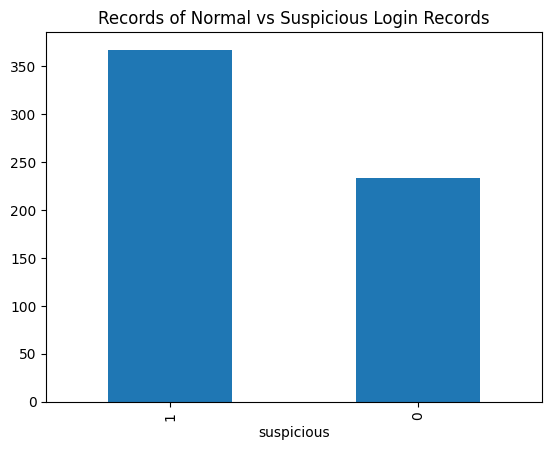

In [23]:
#Visualization

#This chart compares suspicious and normal records.


logs["suspicious"].value_counts().plot(kind="bar", title="Records of Normal vs Suspicious Login Records")


In [24]:
# Toolkit Component 1 — Password Hashing Tool

#This tool demonstrates how passwords can be transformed into SHA-256 hashes.

def hash_password(password):
    return hashlib.sha256(password.encode()).hexdigest()

sample_passwords = ["abc", "MyP@ss123", "pass1234"]

for password in sample_passwords:
    print("Password:", password)
    print("SHA-256 Hash:", hash_password(password))
    print("-" * 60)

Password: abc
SHA-256 Hash: ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
------------------------------------------------------------
Password: MyP@ss123
SHA-256 Hash: 15783160182ec7936c791824ec5ff330cb5c41dc5241b2bd95e50e65e027c3a0
------------------------------------------------------------
Password: pass1234
SHA-256 Hash: bd94dcda26fccb4e68d6a31f9b5aac0b571ae266d822620e901ef7ebe3a11d4f
------------------------------------------------------------


##Reflection:

### Password Hashing Explanation

Hashing converts a password into a fixed-length value that is difficult to reverse. It is used to protect passwords from being stored in plain text.

Hashing is different from encryption because hashing is designed to be one-way, while encrypted data can be decrypted with the correct key.

This tool uses Python's `hashlib` library and SHA-256 to convert each password into a hash before displaying the result.

In [25]:
# Toolkit Component 2 — Caesar Cipher Encryption / Decryption Tool

#This tool demonstrates basic encryption and decryption using a Caesar Cipher.


def caesar_encrypt(text, shift):
    result = ""

    for char in text:
        if char.isalpha():
            base = 65 if char.isupper() else 97
            result += chr((ord(char) - base + shift) % 26 + base)
        else:
            result += char

    return result

def caesar_decrypt(text, shift):
    return caesar_encrypt(text, -shift)

message = "Security 101"
shift = 3

encrypted_message = caesar_encrypt(message, shift)
decrypted_message = caesar_decrypt(encrypted_message, shift)

print("Original message:", message)
print("Encrypted message:", encrypted_message)
print("Decrypted message:", decrypted_message)


Original message: Security 101
Encrypted message: Vhfxulwb 101
Decrypted message: Security 101


### Caesar Cipher Explanation

The Caesar Cipher is a simple encryption method that shifts letters by a fixed number of positions in the alphabet. This tool uses a shift of 3 to encrypt the message and reverses the shift to decrypt it.

The tool demonstrates the basic concepts of encryption and decryption.

In [26]:
# Toolkit Component 3 — Basic Phishing Detector

#This tool checks whether a message contains common phishing keywords.


def phishing_detector(message):
    keywords = ["urgent", "verify", "click", "password", "win", "claim", "locked", "account", "gift card"]

    for word in keywords:
        if word in message.lower():
            return "Potential phishing message detected"

    return "No obvious phishing keywords detected"

messages = [
    "Your account has been locked. Click here to verify your password.",
    "Hi, just checking in about tomorrow's meeting.",
    "You have won a $500 gift card! Claim now."
]

for msg in messages:
    print("Message:", msg)
    print("Result:", phishing_detector(msg))
    print("-" * 60)

Message: Your account has been locked. Click here to verify your password.
Result: Potential phishing message detected
------------------------------------------------------------
Message: Hi, just checking in about tomorrow's meeting.
Result: No obvious phishing keywords detected
------------------------------------------------------------
Message: You have won a $500 gift card! Claim now.
Result: Potential phishing message detected
------------------------------------------------------------


### Basic Phishing Detector Explanation

This tool checks a message for common phishing keywords such as "urgent," "verify," "password," "account," and "click."

If one of these keywords is found, the tool flags the message as a potential phishing message. This is a basic demonstration and may produce false positives or miss more sophisticated phishing attempts.

In [27]:
# Optional Toolkit Component 4 — AI-Based Anomaly Detection

#This optional section uses Isolation Forest to detect unusual login activity.

#If `scikit-learn` is not installed, run:

#`!pip install scikit-learn`


try:
    from sklearn.ensemble import IsolationForest

    features = logs[["login_attempts", "failed_logins", "unusual_login_hour", "new_ip_address"]]

    model = IsolationForest(contamination=0.2, random_state=42)
    logs["ai_anomaly_prediction"] = model.fit_predict(features)

    # In Isolation Forest:
    # -1 = anomaly
    # 1 = normal
    logs["ai_flag"] = logs["ai_anomaly_prediction"].apply(lambda x: "Anomaly" if x == -1 else "Normal")

    print(logs["ai_flag"].value_counts())
    display(logs.head())

except ImportError:
    print("scikit-learn is not installed. Run: !pip install scikit-learn")


ai_flag
Normal     480
Anomaly    120
Name: count, dtype: int64


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious,rule_based_prediction,ai_anomaly_prediction,ai_flag
0,4,0,1,0,0,0,-1,Anomaly
1,5,5,0,0,0,0,1,Normal
2,14,0,0,0,0,0,1,Normal
3,8,8,0,0,0,0,-1,Anomaly
4,21,17,1,0,1,1,1,Normal


# Final Project Reflection

## 1. What suspicious activity did you find?

The dataset contained suspicious login records. Suspicious activity generally involved more failed login attempts, more login attempts, unusual login hours, and new IP addresses.


## 2. Which features helped identify suspicious behavior?

The main features were:

- failed_logins
- login_attempts
- unusual_login_hour
- new_ip_address

## 3. How could cybersecurity analysts use this?

Cybersecurity analysts could use login analysis to identify possible brute-force attacks, unusual access attempts, and suspicious account activity.

## 4. How could AI help?

AI could analyze large amounts of login data and identify unusual patterns more quickly. It could help analysts prioritize activity that may require further investigation.

## 5. What is one risk of relying only on AI?

AI can make mistakes, such as producing false positives or missing real threats. Human review is still important for responsible cybersecurity decisions.
